In [107]:
import pandas as pd
import seaborn as sns
import fnmatch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC,LinearSVC
from sklearn import metrics
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

import shap


----------------------------------------

**Dataset preview**

In [108]:
df = pd.read_csv("./resources/ecommerce_customer_churn_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [109]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


In [110]:
num_rows, num_cols = df.shape
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print(f"Any null values: {df.isnull().values.any()}")
df.head(20)

Number of rows: 50000
Number of columns: 25
Any null values: True


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4
5,35.0,Male,Japan,Tokyo,3.5,6.0,21.9,6.9,74.4,0.0,...,16.0,8.0,2.0,14.3,11.2,2.0,1995.43,2418.0,1,Q1
6,56.0,Male,Germany,Berlin,1.9,24.0,46.4,13.9,36.2,5.0,...,35.5,4.0,6.0,68.8,42.9,5.0,3003.57,2657.0,0,Q1
7,47.0,Female,USA,Houston,1.6,14.0,24.1,8.3,59.9,2.0,...,5.5,5.0,NaN,30.1,7.6,2.0,1394.04,2274.0,0,Q4
8,32.0,Male,Canada,Calgary,1.3,14.0,NaN,7.4,66.5,4.0,...,19.0,2.0,0.0,0.0,18.7,2.0,537.21,534.0,0,Q1
9,44.0,Male,USA,New York,3.6,13.0,31.3,5.4,62.6,3.0,...,11.7,2.0,1.0,13.5,21.5,2.0,807.84,977.0,0,Q2


----------------------------------------

**Data cleanup**
- Remove irrelevant columns
- Remove rows with nulls
- One hot encoding for gender and country columns
- Label encoding for city column
- Show correlation matrix

In [111]:
# Irrelevant columns removal
df_clr = df.drop(columns = ['Social_Media_Engagement_Score', 'Payment_Method_Diversity', 'Signup_Quarter'])
# Dropping rows with null values
df_clr = df_clr.dropna()
# One hot encoding for gender and country columns
df_clr['Gender'].replace(['Female','Male', 'Other'], [0, 1, 2], inplace=True)
df_clr = pd.get_dummies(df_clr, columns=['Country'], drop_first=True)
# Label encoding for city column
df_clr['City'] = df_clr['City'].astype('category').cat.codes

/tmp/ipykernel_7561/1369640480.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clr['Gender'].replace(['Female','Male', 'Other'], [0, 1, 2], inplace=True)
/tmp/ipykernel_7561/1369640480.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clr['Gender'].replace(['Female','Male', 'Other'], [0,

In [112]:
num_rows = df_clr.shape[0]
print(f"Number of rows after dropping nulls: {num_rows}")
df_clr.info()

Number of rows after dropping nulls: 21553
<class 'pandas.core.frame.DataFrame'>
Index: 21553 entries, 0 to 49998
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       21553 non-null  float64
 1   Gender                    21553 non-null  int64  
 2   City                      21553 non-null  int8   
 3   Membership_Years          21553 non-null  float64
 4   Login_Frequency           21553 non-null  float64
 5   Session_Duration_Avg      21553 non-null  float64
 6   Pages_Per_Session         21553 non-null  float64
 7   Cart_Abandonment_Rate     21553 non-null  float64
 8   Wishlist_Items            21553 non-null  float64
 9   Total_Purchases           21553 non-null  float64
 10  Average_Order_Value       21553 non-null  float64
 11  Days_Since_Last_Purchase  21553 non-null  float64
 12  Discount_Usage_Rate       21553 non-null  float64
 13  Returns_Rate           

In [113]:
df_clr.head(20)

,Age,Gender,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,...,Lifetime_Value,Credit_Balance,Churned,Country_Canada,Country_France,Country_Germany,Country_India,Country_Japan,Country_UK,Country_USA
0,43.0,1,21,2.9,14.0,27.4,6.0,50.6,3.0,9.0,...,953.33,2278.0,0,False,True,False,False,False,False,False
1,36.0,1,20,1.6,15.0,42.7,10.3,37.7,1.0,19.5,...,1067.47,3028.0,0,False,False,False,False,False,True,False
2,45.0,0,38,2.9,10.0,24.8,1.6,70.9,1.0,9.1,...,1289.75,2317.0,0,True,False,False,False,False,False,False
3,56.0,0,27,2.6,10.0,38.4,14.8,41.7,9.0,15.0,...,2340.92,2674.0,0,False,False,False,False,False,False,True
5,35.0,1,35,3.5,6.0,21.9,6.9,74.4,0.0,12.0,...,1995.43,2418.0,1,False,False,False,False,True,False,False
6,56.0,1,2,1.9,24.0,46.4,13.9,36.2,5.0,20.0,...,3003.57,2657.0,0,False,False,True,False,False,False,False
10,32.0,1,11,0.9,0.0,12.3,2.9,73.5,0.0,5.0,...,599.41,498.0,1,False,False,False,False,False,True,False
11,32.0,0,25,0.6,11.0,12.1,5.6,77.2,0.0,5.0,...,335.92,1369.0,1,False,False,True,False,False,False,False
13,18.0,0,33,3.1,13.0,26.1,8.9,47.7,2.0,11.0,...,1083.91,2772.0,1,False,False,False,False,False,False,True
14,18.0,0,31,3.7,14.0,33.5,10.3,48.4,2.0,15.0,...,1618.51,3624.0,0,False,True,False,False,False,False,False


In [114]:
df_clr.corr()

,Age,Gender,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,...,Lifetime_Value,Credit_Balance,Churned,Country_Canada,Country_France,Country_Germany,Country_India,Country_Japan,Country_UK,Country_USA
Age,1.000000,0.007176,-0.002885,-0.008999,0.006899,0.003803,0.008140,-0.002357,0.010962,0.005442,...,0.006346,0.001225,-0.114981,-0.008193,0.014754,-0.011940,0.010489,-0.012514,-0.007055,0.011742
Gender,0.007176,1.000000,0.003837,-0.003868,-0.010406,0.004002,0.004832,0.003266,0.003756,0.009470,...,-0.006995,-0.004109,0.003876,0.003511,0.005133,-0.006351,-0.012590,-0.001582,0.000979,0.006847
City,-0.002885,0.003837,1.000000,0.010321,-0.005992,-0.006705,-0.007514,0.006706,-0.005091,-0.010327,...,-0.003179,-0.009026,0.003392,0.246915,0.226460,-0.236913,-0.208663,0.207131,-0.215892,0.035635
Membership_Years,-0.008999,-0.003868,0.010321,1.000000,0.002446,0.009419,0.007449,0.003453,0.002708,-0.024327,...,0.000689,0.000628,0.001607,-0.000066,-0.000635,-0.000357,-0.002480,-0.007321,-0.007313,0.010136
Login_Frequency,0.006899,-0.010406,-0.005992,0.002446,1.000000,0.701226,0.673461,-0.621416,0.594743,0.593557,...,0.489539,0.513101,-0.177059,0.003460,-0.007429,0.005074,0.006283,0.004839,0.003703,-0.013057
Session_Duration_Avg,0.003803,0.004002,-0.006705,0.009419,0.701226,1.000000,0.755379,-0.701072,0.669825,0.664719,...,0.543907,0.566067,-0.210254,-0.006225,-0.011344,0.005657,0.008398,-0.002231,0.003567,-0.001875
Pages_Per_Session,0.008140,0.004832,-0.007514,0.007449,0.673461,0.755379,1.000000,-0.667497,0.636891,0.630447,...,0.522781,0.548008,-0.201823,-0.005441,-0.006595,0.002778,0.005737,-0.003550,0.005645,-0.002845
Cart_Abandonment_Rate,-0.002357,0.003266,0.006706,0.003453,-0.621416,-0.701072,-0.667497,1.000000,-0.589427,-0.583911,...,-0.480525,-0.495618,0.251628,0.001564,0.004777,-0.007648,-0.004187,-0.003165,0.002440,0.002838
Wishlist_Items,0.010962,0.003756,-0.005091,0.002708,0.594743,0.669825,0.636891,-0.589427,1.000000,0.561651,...,0.461294,0.478202,-0.170444,-0.000589,-0.014999,0.006816,0.007299,-0.005289,0.002996,0.001027
Total_Purchases,0.005442,0.009470,-0.010327,-0.024327,0.593557,0.664719,0.630447,-0.583911,0.561651,1.000000,...,0.622440,0.474799,-0.137190,-0.003999,-0.012043,0.004456,0.010950,-0.005556,0.010260,-0.008782


----------------------------------------

**Data analysis**
- Correlation heatmap
- Histogram
- Box plots

<Axes: >

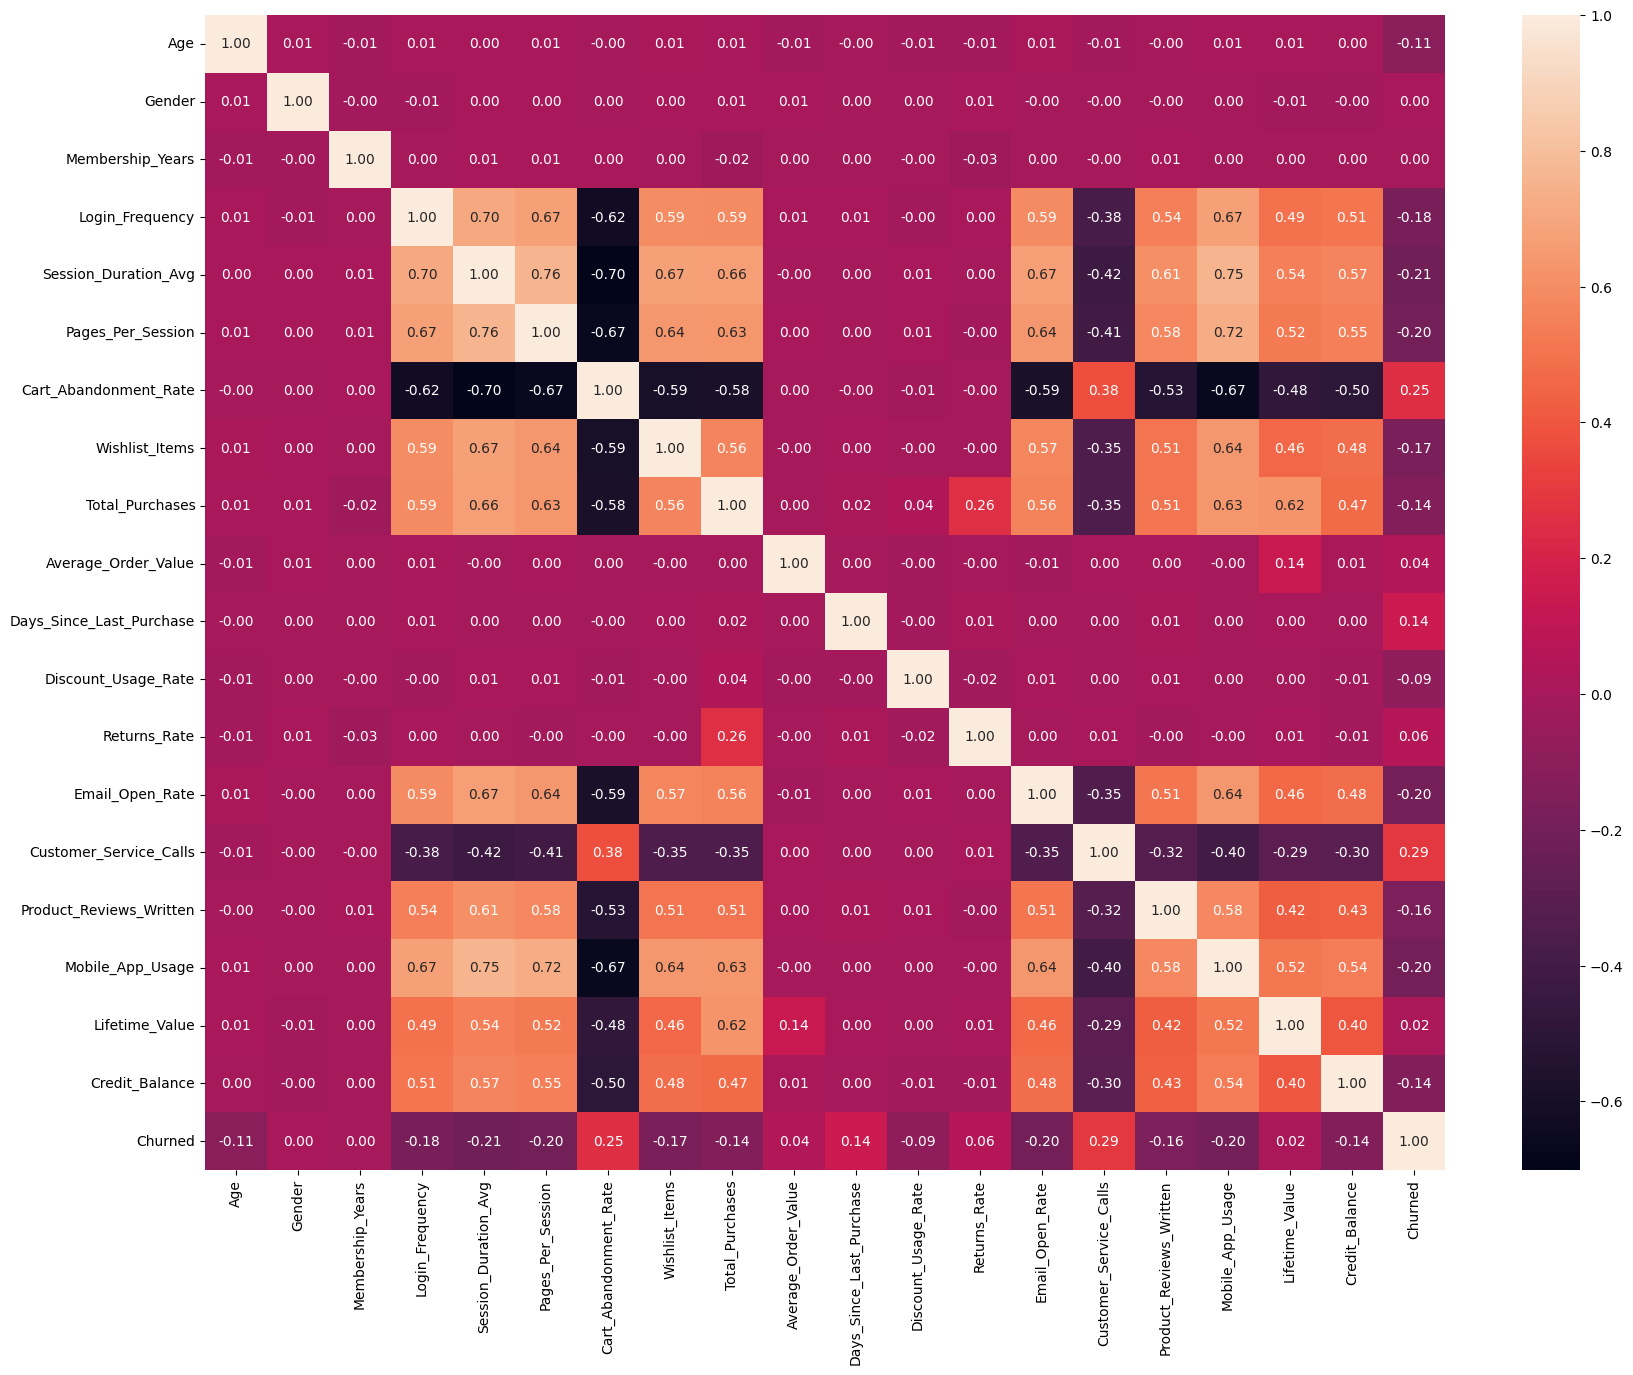

In [115]:
# Correlation heatmap (without city and country encoded columns)
country_cols = fnmatch.filter(df_clr.columns, 'Country_*')
cols_to_drop = ['City'] + country_cols
df_without_encoded = df_clr.drop(columns=cols_to_drop)
plt.subplots(figsize=(20,15))
sns.heatmap(df_without_encoded.corr(), annot=True, fmt=".2f")

In [116]:
# Low target correlation columns removal
df_clr = df_clr.drop(columns = ['Gender', 'Membership_Years'])

Text(0.5, 1.0, 'Age distribution of customers')

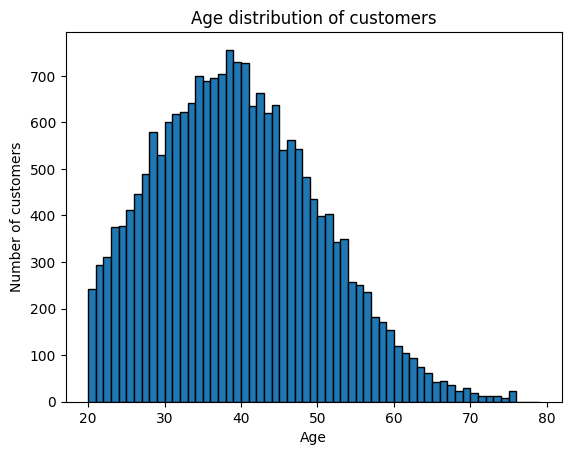

In [117]:
plt.hist(df_clr['Age'], bins=range(20, 80), edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Number of customers')
plt.title('Age distribution of customers')

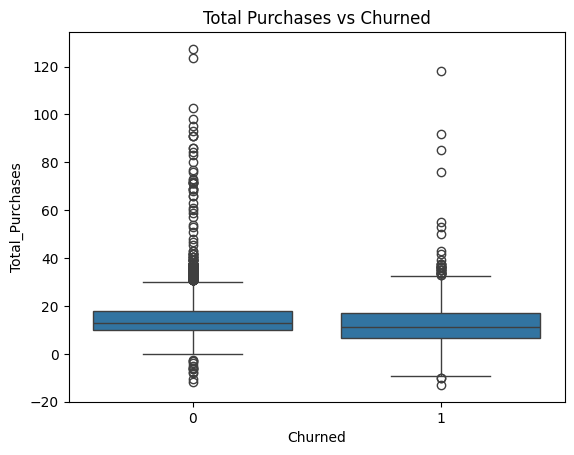

In [118]:
sns.boxplot(x='Churned', y='Total_Purchases', data=df_clr)
plt.title('Total Purchases vs Churned')
plt.show()

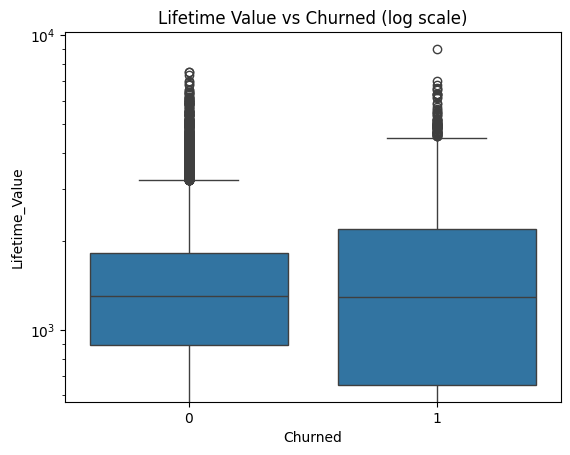

In [119]:
sns.boxplot(x='Churned', y='Lifetime_Value', data=df_clr)
plt.yscale('log')
plt.title('Lifetime Value vs Churned (log scale)')
plt.show()

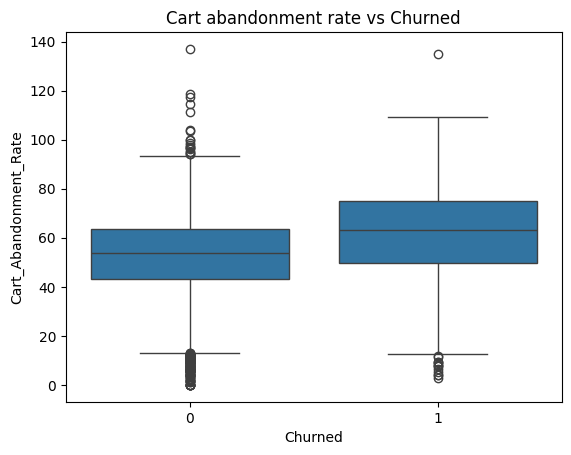

In [120]:
sns.boxplot(x='Churned', y='Cart_Abandonment_Rate', data=df_clr)
plt.title('Cart abandonment rate vs Churned')
plt.show()

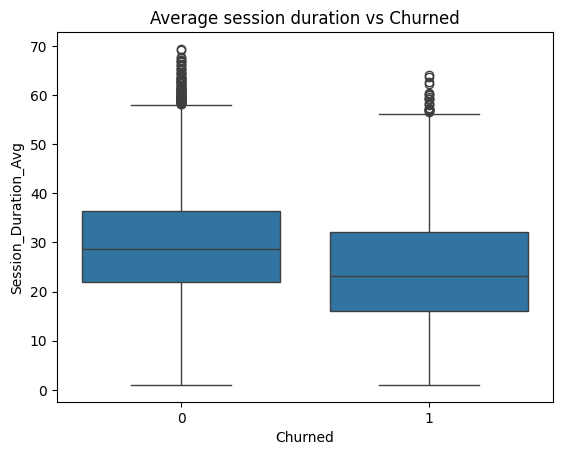

In [121]:
sns.boxplot(x='Churned', y='Session_Duration_Avg', data=df_clr)
plt.title('Average session duration vs Churned')
plt.show()

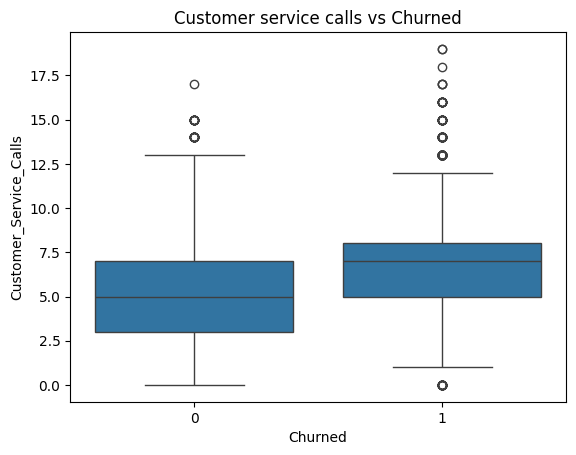

In [122]:
sns.boxplot(x='Churned', y='Customer_Service_Calls', data=df_clr)
plt.title('Customer service calls vs Churned')
plt.show()

----------------------------------------

**Machine learning**
- Prepre data for modelling
- Dataset split for training and testing models
- Training and evaluating models

In [123]:
# Preparing data for modeling
X_names = ['Age', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Mobile_App_Usage', 'Lifetime_Value', 'Credit_Balance'] # features
y_names = ['Churned'] # target

X = df_clr[X_names]
y = df_clr[y_names]

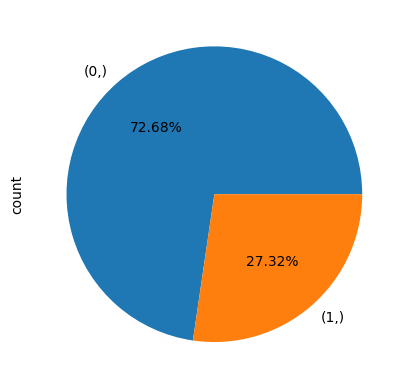

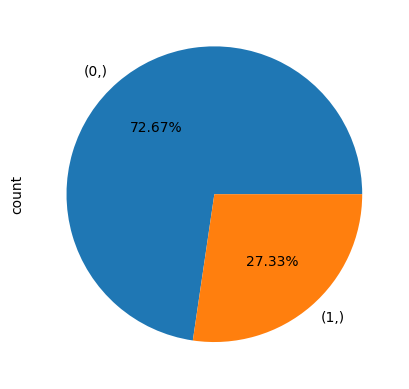

In [124]:
# Splitting dataset into traning and testing sets
# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, train_size=0.8, test_size=0.2, random_state=42)
y_train.value_counts().plot.pie(autopct='%.2f%%') 
plt.show()
y_test.value_counts().plot.pie(autopct='%.2f%%') 
plt.show()

Training and evaluating models

In [125]:
ml_models_results = {}

In [126]:
print('------------------------------------DecisionTree------------------------------------')
dt = DecisionTreeClassifier(criterion='entropy',max_depth=25)
dt.fit(X_train,y_train.values.ravel())
y_pred = dt.predict(X_test)

acc = accuracy_score(y_test.values.ravel(), y_pred)
precision = precision_score(y_test.values.ravel(), y_pred)
recall = recall_score(y_test.values.ravel(), y_pred)
auc = roc_auc_score(y_test.values.ravel(), y_pred)
f1 = f1_score(y_test.values.ravel(), y_pred)

ml_models_results['DecisionTree'] = [acc, precision, recall, auc, f1]

print('accuracy_score:{}, precision:{}, recall:{}, roc-auc:{}, f1-score:{}'.format(acc,precision,recall,auc,f1))
print("Confusion Matrix")
print("{0}".format(metrics.confusion_matrix(y_test.values.ravel(), y_pred)))
print("")
print("Classification Report")
print(metrics.classification_report(y_test.values.ravel(), y_pred))

------------------------------------DecisionTree------------------------------------
accuracy_score:0.8700997448387845, precision:0.7627551020408163, recall:0.7614601018675722, roc-auc:0.8362040375281046, f1-score:0.762107051826678
Confusion Matrix
[[2854  279]
 [ 281  897]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      3133
           1       0.76      0.76      0.76      1178

    accuracy                           0.87      4311
   macro avg       0.84      0.84      0.84      4311
weighted avg       0.87      0.87      0.87      4311



In [127]:
print('------------------------------------RandomForest------------------------------------')
RF = RandomForestClassifier(n_estimators=500)
RF.fit(X_train,y_train.values.ravel())
y_pred = RF.predict(X_test)

acc = accuracy_score(y_test.values.ravel(), y_pred)
precision = precision_score(y_test.values.ravel(), y_pred)
recall = recall_score(y_test.values.ravel(), y_pred)
auc = roc_auc_score(y_test.values.ravel(), y_pred)
f1 = f1_score(y_test.values.ravel(), y_pred)

ml_models_results['RandomForest'] = [acc, precision, recall, auc, f1]

print('accuracy_score:{}, precision:{}, recall:{}, roc-auc:{}, f1-score:{}'.format(acc,precision,recall,auc,f1))
print("Confusion Matrix")
print("{0}".format(metrics.confusion_matrix(y_test.values.ravel(), y_pred)))
print("")
print("Classification Report")
print(metrics.classification_report(y_test.values.ravel(), y_pred))

------------------------------------RandomForest------------------------------------
accuracy_score:0.9239155648341452, precision:0.9207920792079208, recall:0.7894736842105263, roc-auc:0.8819695264333832, f1-score:0.850091407678245
Confusion Matrix
[[3053   80]
 [ 248  930]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      3133
           1       0.92      0.79      0.85      1178

    accuracy                           0.92      4311
   macro avg       0.92      0.88      0.90      4311
weighted avg       0.92      0.92      0.92      4311



In [128]:
print('------------------------------------svm_linear------------------------------------')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
svm_linear = LinearSVC(max_iter=100000, C=0.1, penalty='l2', random_state=42)
svm_linear.fit(X_train_scaled, y_train.values.ravel())
y_pred = svm_linear.predict(X_test_scaled)

acc = accuracy_score(y_test.values.ravel(), y_pred)
precision = precision_score(y_test.values.ravel(), y_pred)
recall = recall_score(y_test.values.ravel(), y_pred)
auc = roc_auc_score(y_test.values.ravel(), y_pred)
f1 = f1_score(y_test.values.ravel(), y_pred)

ml_models_results['SVM_Linear'] = [acc, precision, recall, auc, f1]

print('accuracy_score:{}, precision:{}, recall:{}, roc-auc:{}, f1-score:{}'.format(acc,precision,recall,auc,f1))
print("Confusion Matrix")
print("{0}".format(metrics.confusion_matrix(y_test.values.ravel(), y_pred)))
print("")
print("Classification Report")
print(metrics.classification_report(y_test.values.ravel(), y_pred))

------------------------------------svm_linear------------------------------------
accuracy_score:0.7780097425191371, precision:0.6796747967479675, recall:0.3548387096774194, roc-auc:0.6459798399967053, f1-score:0.4662576687116564
Confusion Matrix
[[2936  197]
 [ 760  418]]

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.94      0.86      3133
           1       0.68      0.35      0.47      1178

    accuracy                           0.78      4311
   macro avg       0.74      0.65      0.66      4311
weighted avg       0.76      0.78      0.75      4311



In [129]:
print('------------------------------------XGBoost------------------------------------')
xgb = XGBClassifier(eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train.values.ravel())
y_pred = xgb.predict(X_test)

acc = accuracy_score(y_test.values.ravel(), y_pred)
precision = precision_score(y_test.values.ravel(), y_pred)
recall = recall_score(y_test.values.ravel(), y_pred)
auc = roc_auc_score(y_test.values.ravel(), y_pred)
f1 = f1_score(y_test.values.ravel(), y_pred)

ml_models_results['XGBoost'] = [acc, precision, recall, auc, f1]

print('accuracy_score:{}, precision:{}, recall:{}, roc-auc:{}, f1-score:{}'.format(acc,precision,recall,auc,f1))
print("Confusion Matrix")
print("{0}".format(metrics.confusion_matrix(y_test.values.ravel(), y_pred)))
print("")
print("Classification Report")
print(metrics.classification_report(y_test.values.ravel(), y_pred))

------------------------------------XGBoost------------------------------------
accuracy_score:0.9250753885409417, precision:0.9130434782608695, recall:0.8022071307300509, roc-auc:0.8867403352341605, f1-score:0.8540442837776774
Confusion Matrix
[[3043   90]
 [ 233  945]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      3133
           1       0.91      0.80      0.85      1178

    accuracy                           0.93      4311
   macro avg       0.92      0.89      0.90      4311
weighted avg       0.92      0.93      0.92      4311



----------------------------------------

**XAI - Machine learning**
- Selects best model based on its results
- Explains model with SHAP

In [130]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'AUC', 'F1-Score']
print("Best ML model based on...\n")
best_counts = {}
for i, metric in enumerate(metric_names):
    best_model = max(ml_models_results.items(), key=lambda x: x[1][i])
    print(f"{metric}: {best_model[0]} (score: {best_model[1][i]:.4f})")
    best_counts[best_model[0]] = best_counts.get(best_model[0], 0) + 1

print("\nModel win counts:")
for model, count in best_counts.items():
    print(f"{model}: {count} wins")

overall_best = max(best_counts.items(), key=lambda x: x[1])
print(f"\nOverall best model (most wins): {overall_best[0]} with {overall_best[1]} wins")

Best ML model based on...

Accuracy: XGBoost (score: 0.9251)
Precision: RandomForest (score: 0.9208)
Recall: XGBoost (score: 0.8022)
AUC: XGBoost (score: 0.8867)
F1-Score: XGBoost (score: 0.8540)

Model win counts:
XGBoost: 4 wins
RandomForest: 1 wins

Overall best model (most wins): XGBoost with 4 wins


In [131]:
# Select the best model based on overall_best
model_dict = {
    'DecisionTree': dt,
    'RandomForest': RF,
    'SVM_Linear': svm_linear,
    'XGBoost': xgb
}
model = model_dict[overall_best[0]]
observation_idx = 0

# Validate observation_idx
if not (0 <= observation_idx < len(X_test)):
    print(f"observation_idx {observation_idx} out of range for X_test (len={len(X_test)}). Resetting to 0.")
    observation_idx = 0

# Use appropriate SHAP explainer based on model type
if overall_best[0] == 'SVM_Linear':
    scaler_shap = StandardScaler()
    X_train_scaled = scaler_shap.fit_transform(X_train)
    X_test_scaled = scaler_shap.transform(X_test)
    
    # Conversion of scaled arrays to DataFrame in order to preserve feature names for SHAP plots
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_names)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_names)
    explainer = shap.LinearExplainer(model, X_train_scaled_df)
    shap_values = explainer(X_test_scaled_df.iloc[observation_idx:observation_idx + 1])
    sample_for_plot = X_test_scaled_df.iloc[observation_idx]
elif overall_best[0] == 'XGBoost':
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test.iloc[observation_idx:observation_idx + 1])
    sample_for_plot = X_test.iloc[observation_idx]
else:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test.iloc[observation_idx:observation_idx + 1])
    sample_for_plot = X_test.iloc[observation_idx]

shap.initjs()

shap_values_for_sample = shap_values.values[0]
base_value = shap_values.base_values[0]

shap.force_plot(base_value, shap_values_for_sample, sample_for_plot, feature_names=X_names)

----------------------------------------

**Deep learning**
- Prepare labels and features for training
- Build deep learning model suitable for tabular data

In [132]:
# Prepare labels and features for training (StandardScaler for features)
y_train = y_train.values.ravel().astype('float32')
y_test = y_test.values.ravel().astype('float32')

scaler_dl = StandardScaler()
X_train = scaler_dl.fit_transform(X_train.astype('float32'))
X_test = scaler_dl.transform(X_test.astype('float32'))

In [133]:
# Binary classification model suitable for tabular data
input_dim = X_train.shape[1]
ssn = Sequential()
ssn.add(Input(shape=(input_dim,)))
ssn.add(Dense(512, activation='selu', kernel_regularizer=regularizers.l2(0.001)))
ssn.add(Dropout(0.3))
ssn.add(Dense(256, activation='selu', kernel_regularizer=regularizers.l2(0.001)))
ssn.add(Dropout(0.3))
ssn.add(Dense(1, activation='sigmoid'))

ssn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
ssn.summary()

checkpoint = ModelCheckpoint('best_model.h5', monitor='val_auc', mode='max', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True, verbose=1)

training_history = ssn.fit(X_train, y_train, epochs=5, verbose=1, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, checkpoint])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,801 (550.00 KB)

 Trainable params: 140,801 (550.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
534/539 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7559 - auc: 0.7441 - loss: 0.8253
Epoch 1: val_auc improved from None to 0.84377, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
539/539 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7784 - auc: 0.7804 - loss: 0.7328 - val_accuracy: 0.8151 - val_auc: 0.8438 - val_loss: 0.5725
Epoch 2/5
534/539 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8073 - auc: 0.8197 - loss: 0.5728
Epoch 2: val_auc did not improve from 0.84377
539/539 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8106 - auc: 0.8251 - loss: 0.5495 - val_accuracy: 0.8174 - val_auc: 0.8410 - val_loss: 0.4943
Epoch 3/5
530/539 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8195 - auc: 0.8425 - loss: 0.4898
Epoch 3: val_auc improved from 0.84377 to 0.87705, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
539/539 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8181 - auc: 0.8437 - loss: 0.4831 - val_accuracy: 0.8399 - val_auc: 0.8770 - val_loss: 0.4394
Epoch 4/5
530/539 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8226 - auc: 0.8520 - loss: 0.4614
Epoch 4: val_auc improved from 0.87705 to 0.88582, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
539/539 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8265 - auc: 0.8555 - loss: 0.4535 - val_accuracy: 0.8515 - val_auc: 0.8858 - val_loss: 0.4192
Epoch 5/5
536/539 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8319 - auc: 0.8601 - loss: 0.4461
Epoch 5: val_auc improved from 0.88582 to 0.88588, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
539/539 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8353 - auc: 0.8654 - loss: 0.4384 - val_accuracy: 0.8462 - val_auc: 0.8859 - val_loss: 0.4092
Restoring model weights from the end of the best epoch: 5.


----------------------------------------

**XAI - Deep learning**
- Explains model with SHAP

/home/mateusz/Studia/informatyka_ogolna/sztuczna_inteligencja/projekt/.venv/lib64/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_32
Received: inputs=['Tensor(shape=(100, 17))']
  warnings.warn(msg)
/home/mateusz/Studia/informatyka_ogolna/sztuczna_inteligencja/projekt/.venv/lib64/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_32
Received: inputs=['Tensor(shape=(50, 17))']
  warnings.warn(msg)


/tmp/ipykernel_7561/3736864175.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_dl.values[:, :, 0], X_test[:100], feature_names=X_names)


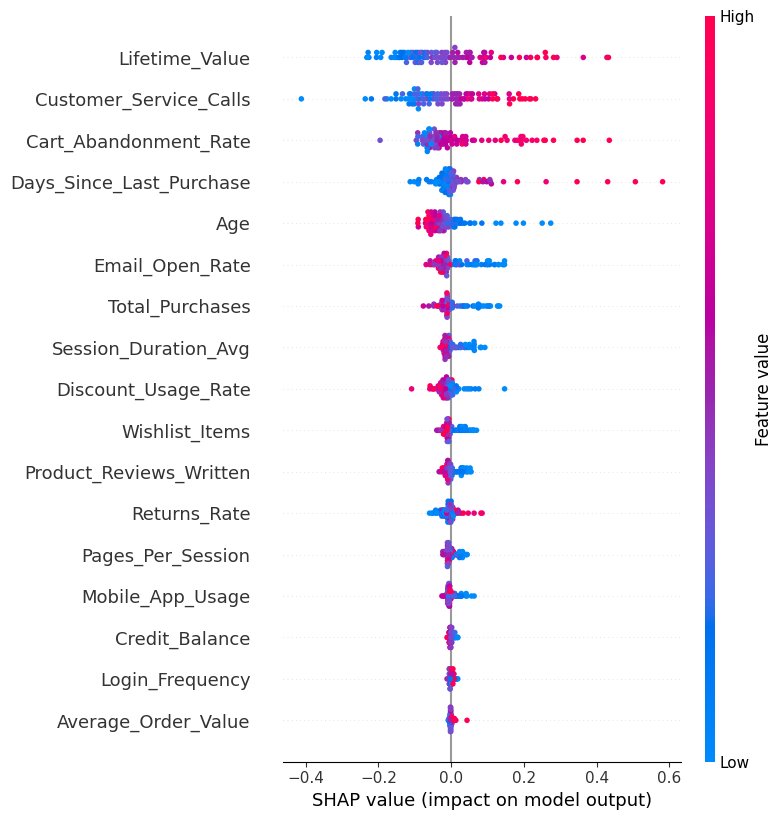

In [134]:
# SHAP explanation for Deep Learning model
explainer_dl = shap.GradientExplainer(ssn, X_train[:100])
shap_values_dl = explainer_dl(X_test[:100])

shap.initjs()
shap.summary_plot(shap_values_dl.values[:, :, 0], X_test[:100], feature_names=X_names)